In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",delimiter=";")

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
X = df.drop(columns=['quality'],axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)


In [ ]:
# Print classification report for decision tree model
y_pred = dt.predict(X_test)
print("Decision Tree")
print(classification_report(y_test, y_pred))

Decision Tree
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.63      0.68      0.65       130
           6       0.55      0.53      0.54       132
           7       0.51      0.50      0.51        42
           8       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.28      0.28      0.28       320
weighted avg       0.55      0.56      0.55       320



In [ ]:
# Train Bagging classifier
bagging = BaggingClassifier(base_estimator=DecisionTreeClassifier(),
n_estimators=100, random_state=42)
bagging.fit(X_train, y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=42)

In [ ]:
# Print classification report for Bagging classifier
y_pred = bagging.predict(X_test)
print("Bagging")
print(classification_report(y_test, y_pred))

Bagging
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.78      0.75       130
           6       0.63      0.68      0.66       132
           7       0.59      0.48      0.53        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.32      0.32      0.32       320
weighted avg       0.63      0.66      0.64       320



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# Train Pasting classifier
pasting = BaggingClassifier(base_estimator=DecisionTreeClassifier(),
n_estimators=100, bootstrap=False, random_state=42)
pasting.fit(X_train, y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingClassifier(base_estimator=DecisionTreeClassifier(), bootstrap=False,
                  n_estimators=100, random_state=42)

In [ ]:
# Print classification report for Pasting classifier
y_pred = pasting.predict(X_test)
print("Pasting")
print(classification_report(y_test, y_pred))

Pasting
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.64      0.66      0.65       130
           6       0.56      0.54      0.55       132
           7       0.53      0.55      0.54        42
           8       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.29      0.29      0.29       320
weighted avg       0.56      0.56      0.56       320



In [ ]:
# Evaluate Out-of-Bag score for Bagging classifier
bagging_ob = BaggingClassifier(base_estimator=DecisionTreeClassifier(),
n_estimators=100, oob_score=True,
random_state=42)
bagging_ob.fit(X_train, y_train)
oob_score = bagging_ob.oob_score_
print("Out-of-Bag Score")
print("OOB Score:", oob_score)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Out-of-Bag Score
OOB Score: 0.6942924159499609


In [ ]:
# Plot confusion matrix for Bagging classifier
cm=confusion_matrix(y_test,y_pred)
cm

array([[ 0,  0,  0,  1,  0,  0],
       [ 0,  0,  6,  4,  0,  0],
       [ 1,  7, 86, 33,  3,  0],
       [ 0,  4, 40, 71, 15,  2],
       [ 0,  0,  2, 15, 23,  2],
       [ 0,  0,  1,  2,  2,  0]])

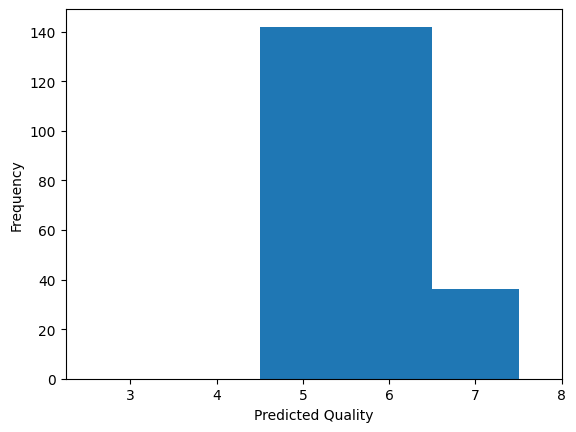

In [ ]:
# Plot histogram of predicted quality values for Bagging classifier
y_pred = bagging.predict(X_test)
plt.hist(y_pred, bins=range(3, 9), align='left')
plt.xticks(range(3, 9))
plt.xlabel("Predicted Quality")
plt.ylabel("Frequency")
plt.show()